<a href="https://colab.research.google.com/github/Sounak-thegeek/SMSSpamClassifier/blob/main/Spam_Ham_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup and Data Loading

In [1]:
# Install the gensim library for Word2Vec.
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.8 MB/s eta 0:00:00


In [2]:
# Import necessary modules from gensim.
import gensim
from gensim.models import Word2Vec, KeyedVectors

In [3]:
# Load the dataset into a pandas DataFrame.
import pandas as pd
messages = pd.read_csv('/content/sample_data/SMSSpamCollection', sep='\t', names=["label", "message"])

In [4]:
# Display the first few rows of the DataFrame to inspect the data.
messages

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


# 2. Text Preprocessing

In [5]:
# Import WordNetLemmatizer for reducing words to their base form.
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [6]:
# Import the regular expression module for text cleaning.
import re

In [7]:
# Download the WordNet corpus for lemmatization.
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [8]:
# Download 'punkt_tab' for tokenization, if needed.
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
# Create a corpus of preprocessed messages.
corpus = []
for i in range(0, len(messages)):
  # Remove non-alphabetic characters and convert to lowercase.
  review = re.sub('[^a-zA-Z]', ' ', messages['message'][i])
  review = review.lower()
  # Split into words.
  review = review.split()
  # Lemmatize words to their base form.
  review = [lemmatizer.lemmatize(word) for word in review]
  corpus.append(review)

In [10]:
# Check for any empty reviews in the corpus.
[[i,j,k] for i,j,k in zip(list(map(len,corpus)),corpus, messages['message']) if i<1]

[[0, [], '645'], [0, [], ':) '], [0, [], ':-) :-)']]

In [11]:
# Import necessary NLTK and gensim utilities.
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

In [12]:
# Assign the preprocessed corpus to a variable named 'words' for clarity.
words = corpus

# 3. Word2Vec Model Training and Vectorization

In [13]:
# Train a Word2Vec model on the preprocessed text corpus.
model = gensim.models.Word2Vec(words)

In [14]:
# Display the vocabulary learned by the Word2Vec model.
model.wv.index_to_key

['i',
 'to',
 'you',
 'a',
 'the',
 'u',
 'and',
 'it',
 'in',
 'is',
 'me',
 'my',
 'for',
 'your',
 'call',
 'of',
 's',
 'that',
 'have',
 'on',
 't',
 'now',
 'are',
 'can',
 'm',
 'so',
 'but',
 'not',
 'or',
 'we',
 'do',
 'get',
 'at',
 'ur',
 'if',
 'will',
 'be',
 'with',
 'no',
 'just',
 'this',
 'gt',
 'lt',
 'go',
 'how',
 'up',
 'when',
 'day',
 'ok',
 'what',
 'free',
 'from',
 'all',
 'out',
 'know',
 'll',
 'come',
 'like',
 'good',
 'time',
 'am',
 'then',
 'got',
 'wa',
 'there',
 'he',
 'love',
 'text',
 'only',
 'want',
 'send',
 'p',
 'r',
 'one',
 'need',
 'txt',
 'today',
 'n',
 'by',
 'going',
 'c',
 'don',
 'stop',
 'she',
 'home',
 'about',
 'lor',
 'sorry',
 'k',
 'see',
 'still',
 'mobile',
 'take',
 'd',
 'back',
 'da',
 'reply',
 'dont',
 'our',
 'think',
 'tell',
 'week',
 'phone',
 'hi',
 'new',
 'they',
 'later',
 'please',
 'any',
 'pls',
 'her',
 'ha',
 'did',
 'co',
 'msg',
 'been',
 'min',
 'an',
 'some',
 'dear',
 'night',
 'make',
 'who',
 'here',

In [15]:
# Show the number of documents (messages) used for training the Word2Vec model.
model.corpus_count

5572

In [16]:
# Display the number of training epochs for the Word2Vec model.
model.epochs

5

In [17]:
# Find words most similar to 'glad' based on learned word embeddings.
model.wv.similar_by_word('glad')

[('god', 0.9948307275772095),
 ('kiss', 0.9946275353431702),
 ('lol', 0.9946247339248657),
 ('mind', 0.994574248790741),
 ('were', 0.9945497512817383),
 ('care', 0.9945408701896667),
 ('told', 0.9945265650749207),
 ('heart', 0.9944961071014404),
 ('really', 0.9944782853126526),
 ('quite', 0.9944626688957214)]

In [18]:
# Retrieve the vector representation for the word 'sunny'.
model.wv['sunny']

array([-0.03716031,  0.05278679,  0.0058451 ,  0.02207131,  0.01281503,
       -0.14647527,  0.03741162,  0.19656925, -0.07917497, -0.04912673,
       -0.02789289, -0.11185176, -0.03715032,  0.06954733,  0.01088883,
       -0.042657  ,  0.00355836, -0.08005463, -0.02812051, -0.14317302,
        0.02502485,  0.00239776,  0.04815692, -0.01346265, -0.00637176,
        0.00031442, -0.03839104, -0.04832362, -0.03229522, -0.00906079,
        0.09831779, -0.02066175,  0.05276343, -0.04970189, -0.03387225,
        0.10833672,  0.01834946, -0.06698623, -0.06489194, -0.12491158,
        0.03232605, -0.07585806, -0.03094917,  0.03152858,  0.06473901,
       -0.0196887 , -0.03878563, -0.03340899,  0.02900873,  0.03363415,
        0.01421552, -0.07116375, -0.02096637, -0.011801  , -0.01681171,
        0.02333647,  0.02773753, -0.0103811 , -0.05997759,  0.01644243,
        0.00716152,  0.00059165,  0.01549456, -0.03713714, -0.09848337,
        0.11432065,  0.06673995,  0.07209695, -0.12850766,  0.11

In [19]:
# Import numpy for numerical operations.
import numpy as np

In [20]:
# Define a function to calculate the average Word2Vec vector for a document.
def avg_word2vec(doc):
  # Filter out words not present in the model's vocabulary.
  word_vectors = [model.wv[word] for word in doc if word in model.wv.index_to_key]
  if len(word_vectors) == 0:
    # Return a zero vector if no words from the document are in the vocabulary.
    return np.zeros(model.vector_size)
  # Compute the mean of word vectors to get a document vector.
  return np.mean(word_vectors, axis=0)

In [21]:
# Install tqdm for displaying progress bars during iterations.
!pip install tqdm

In [22]:
# Import tqdm for progress bar functionality.
from tqdm import tqdm

In [23]:
# Apply the avg_word2vec function to each message in the corpus.
X=[]
for i in tqdm(range(len(words))):
  X.append(avg_word2vec(words[i]))

100%|██████████| 5572/5572 [00:00<00:00, 6550.48it/s]


In [24]:
# Convert the list of document vectors to a NumPy array.
X_new = np.array(X)

In [25]:
# Check the shape of the vectorized data.
X_new.shape

(5572, 100)

# 4. Prepare Data for Model Training

In [26]:
# Convert categorical labels ('ham', 'spam') into numerical (one-hot encoded) format.
y = pd.get_dummies(messages['label'])

In [27]:
# Select the 'ham' column as the target variable (True for ham, False for spam).
y = y.iloc[:, 0].values

In [28]:
# Display the processed target variable.
y

array([ True,  True, False, ...,  True,  True,  True])

In [29]:
# Convert the list of word vectors into a pandas DataFrame.
df_rows = []
for i in range(0, len(X)):
  df_rows.append(pd.DataFrame(X[i].reshape(1, -1)))
df = pd.concat(df_rows, ignore_index=True)

In [30]:
# Check the shape of the DataFrame containing features.
df.shape

(5572, 100)

In [31]:
# Display the first few rows of the feature DataFrame.
df.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.103434,0.213808,0.050790,0.069265,0.009876,-0.527812,0.175980,0.749901,-0.314818,-0.176237,...,0.295990,0.104801,0.107831,0.081945,0.514894,0.289305,0.120346,-0.281489,0.110283,-0.014949
1,-0.105986,0.194532,0.073373,0.066896,-0.011685,-0.486424,0.161963,0.683152,-0.299123,-0.168313,...,0.289223,0.105170,0.088945,0.092671,0.487623,0.296116,0.093051,-0.248220,0.085403,-0.014436
2,-0.095868,0.225121,0.027168,0.084612,0.007939,-0.546290,0.185095,0.804641,-0.332054,-0.175961,...,0.295594,0.112114,0.125770,0.077619,0.512024,0.270007,0.175436,-0.305724,0.120028,0.012042
3,-0.154377,0.259770,0.087591,0.099819,-0.018085,-0.669456,0.225905,0.971461,-0.411262,-0.231007,...,0.401812,0.147465,0.131366,0.123828,0.679607,0.406872,0.145524,-0.355567,0.124136,-0.010507
4,-0.136251,0.218255,0.084546,0.108494,-0.026300,-0.578683,0.200055,0.827098,-0.349160,-0.196784,...,0.348011,0.122644,0.119397,0.116670,0.598297,0.367180,0.130857,-0.286103,0.082583,-0.011944


In [32]:
# Add the target variable ('Output') to the feature DataFrame.
df['Output'] = y

In [33]:
# Display the DataFrame including the new 'Output' column.
df.head()

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,Output
0,-0.103434,0.213808,0.050790,0.069265,0.009876,-0.527812,0.175980,0.749901,-0.314818,-0.176237,...,0.104801,0.107831,0.081945,0.514894,0.289305,0.120346,-0.281489,0.110283,-0.014949,True
1,-0.105986,0.194532,0.073373,0.066896,-0.011685,-0.486424,0.161963,0.683152,-0.299123,-0.168313,...,0.105170,0.088945,0.092671,0.487623,0.296116,0.093051,-0.248220,0.085403,-0.014436,True
2,-0.095868,0.225121,0.027168,0.084612,0.007939,-0.546290,0.185095,0.804641,-0.332054,-0.175961,...,0.112114,0.125770,0.077619,0.512024,0.270007,0.175436,-0.305724,0.120028,0.012042,False
3,-0.154377,0.259770,0.087591,0.099819,-0.018085,-0.669456,0.225905,0.971461,-0.411262,-0.231007,...,0.147465,0.131366,0.123828,0.679607,0.406872,0.145524,-0.355567,0.124136,-0.010507,True
4,-0.136251,0.218255,0.084546,0.108494,-0.026300,-0.578683,0.200055,0.827098,-0.349160,-0.196784,...,0.122644,0.119397,0.116670,0.598297,0.367180,0.130857,-0.286103,0.082583,-0.011944,True


In [34]:
# Remove any rows with missing values (if any) from the DataFrame.
df.dropna(inplace=True)

In [35]:
# Verify that there are no remaining null values in the DataFrame.
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
96,0
97,0
98,0
99,0


In [36]:
# Separate features (X) from the target variable.
X = df.iloc[:,:100]

In [37]:
# Assign the 'Output' column as the target variable (y).
y=df['Output']

In [38]:
# Split the data into training and testing sets.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [39]:
# Display the training features.
X_train

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
5280,-0.010397,0.299318,-0.135254,-0.224803,0.247648,-0.678320,0.241364,0.863076,-0.182491,-0.192684,...,0.270965,0.083563,0.127576,0.045370,0.444595,0.187010,-0.031953,-0.507649,0.204660,-0.315505
1001,-0.093154,0.177040,0.049121,0.069051,-0.002107,-0.453094,0.155032,0.647912,-0.271767,-0.151408,...,0.263187,0.085593,0.090094,0.071283,0.446749,0.258915,0.103736,-0.235661,0.092826,-0.011202
4107,-0.143907,0.240437,0.091028,0.115157,-0.009217,-0.624465,0.213731,0.906961,-0.404278,-0.215181,...,0.381026,0.157572,0.135710,0.118915,0.650916,0.384008,0.146847,-0.294228,0.102372,-0.010881
966,-0.110208,0.264683,0.022118,0.011871,0.051615,-0.671422,0.235447,0.934385,-0.348791,-0.213479,...,0.366815,0.131801,0.135628,0.097200,0.610112,0.345352,0.109187,-0.377898,0.144309,-0.095900
1870,-0.149124,0.223157,0.091959,0.116289,-0.018967,-0.614100,0.214670,0.886224,-0.387062,-0.204361,...,0.381260,0.145675,0.136050,0.128112,0.651225,0.396760,0.149063,-0.285324,0.083686,-0.013215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3114,-0.138138,0.251830,0.073785,0.087385,0.006398,-0.647945,0.219319,0.918212,-0.387836,-0.220857,...,0.375701,0.136786,0.134059,0.118501,0.646504,0.375676,0.125987,-0.339833,0.119815,-0.037927
3033,-0.110887,0.243204,0.055913,0.082667,0.003069,-0.610143,0.202953,0.861759,-0.364670,-0.197140,...,0.337489,0.121415,0.124071,0.089787,0.580810,0.320918,0.145808,-0.316866,0.130433,-0.006702
523,-0.131990,0.244793,0.075100,0.103317,-0.008603,-0.640348,0.213675,0.908998,-0.385365,-0.215429,...,0.370903,0.138808,0.126612,0.108773,0.643209,0.370919,0.147691,-0.322564,0.113492,-0.000207
4920,-0.117619,0.234791,0.061519,0.107888,-0.015286,-0.579231,0.202982,0.836706,-0.364191,-0.197292,...,0.342002,0.126042,0.126126,0.106422,0.596404,0.331378,0.166765,-0.280091,0.095651,0.012405


In [40]:
# Display the training labels.
y_train

,Output
5280,True
1001,True
4107,True
966,True
1870,True
...,...
3114,True
3033,True
523,True
4920,True


# 5. Model Training and Evaluation

In [41]:
# Import the RandomForestClassifier from scikit-learn.
from sklearn.ensemble import RandomForestClassifier

In [42]:
# Instantiate a RandomForestClassifier model.
classifier = RandomForestClassifier()

In [43]:
# Train the RandomForestClassifier model using the training data.
classifier.fit(X_train, y_train)

RandomForestClassifier()

In [44]:
# Make predictions on the test set using the trained model.
y_pred = classifier.predict(X_test)

In [45]:
# Import evaluation metrics from scikit-learn.
from sklearn.metrics import accuracy_score, classification_report

In [46]:
# Calculate and display the accuracy score of the model.
accuracy_score(y_test, y_pred)

0.9757847533632287

In [47]:
# Print the classification report, including precision, recall, and f1-score.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.92      0.89      0.91       145
        True       0.98      0.99      0.99       970

    accuracy                           0.98      1115
   macro avg       0.95      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



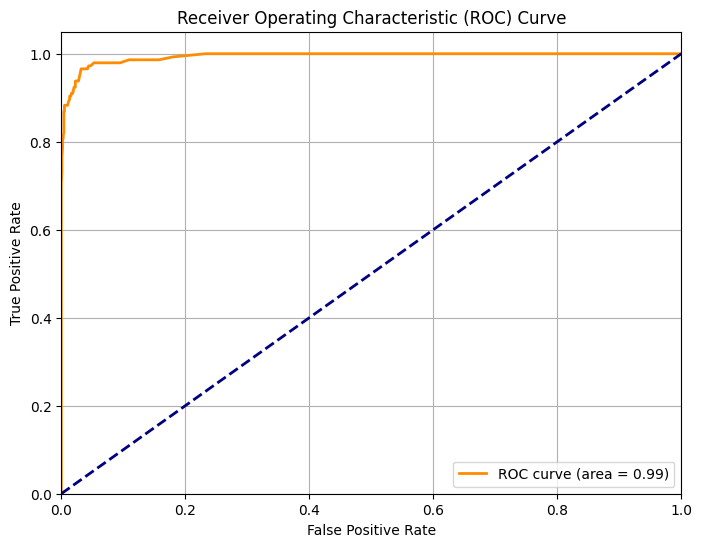

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Convert y_test to numeric (0 or 1) for ROC curve calculation
y_test_numeric = y_test.astype(int)

# Determine the positive class and calculate probabilities for the ROC curve
# This logic handles cases where True/False might be ordered differently by the classifier
if False in classifier.classes_ and True in classifier.classes_:
    # If False is at index 0 and True at index 1
    if list(classifier.classes_)[0] == False:
        # Probability of 'False' (which corresponds to Spam if 'ham' is True)
        y_pred_proba = classifier.predict_proba(X_test)[:, 0]
        # roc_curve expects positive class to be 1, so if False is spam and mapped to 0, invert y_test for roc_curve
        fpr, tpr, thresholds = roc_curve(1 - y_test_numeric, y_pred_proba)
    # If True is at index 0 and False at index 1 (unlikely for default boolean handling)
    elif list(classifier.classes_)[0] == True:
        # Probability of 'False' (Spam)
        y_pred_proba = classifier.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(1 - y_test_numeric, y_pred_proba)

# Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Plot the random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()